# Lab 6.2 — LangGraph with Tools, Memory & Checkpointing

## Introduction

This is the **second lab** in the LangGraph module, building on [Lab 6.1](6_lab1.ipynb). You will upgrade a simple graph into a **full agent** that can search the web, send email, remember conversations, and persist state to disk.

The lab covers four major concepts:
1. **Tools** — bind search and email tools to an LLM using LangChain's `Tool` wrapper and LangGraph's `ToolNode`
2. **Conditional edges** — route between the chatbot and tool nodes with `tools_condition`
3. **Memory** — use `MemorySaver` checkpointing so state persists across super-steps
4. **SQLite persistence** — store checkpoints in `memory.db` for durable conversation history

Before starting, make sure you have:
- Completed Lab 6.1 and LangSmith setup
- `OPENAI_API_KEY`, `YOUR_EMAIL`, and `YOUR_NAME` in your `.env` file
- `SERPER_API_KEY` for Google search (via `GoogleSerperAPIWrapper`)
- `MAILER_SEND_API_TOKEN` and `MAILER_SEND_DOMAIN` for email (see Lab 3.2)

---

## Intention (Learning Objectives)

By the end of this lab, you should be able to:

1. **Wrap external APIs as LangChain tools** — use `GoogleSerperAPIWrapper` and custom functions with `Tool()`
2. **Build a tool-calling graph** — combine `ChatOpenAI.bind_tools()`, `ToolNode`, and conditional edges
3. **Understand super-steps vs. memory** — know why reducers handle within-step updates but checkpointing handles between-step persistence
4. **Add in-memory checkpointing** — use `MemorySaver` with a `thread_id` config
5. **Inspect graph state** — read current state and state history with `get_state()` and `get_state_history()`
6. **Persist to SQLite** — swap `MemorySaver` for `SqliteSaver` to survive notebook restarts

---

## Lab Structure

| Part | Content |
|------|---------|
| **Part 1** | Setup — imports and environment variables |
| **Part 2** | Build tools — web search (Serper) and email (MailerSend) |
| **Part 3** | Tool-calling graph — chatbot node, `ToolNode`, conditional edges |
| **Part 4** | Gradio UI without memory |
| **Part 5** | Add memory with `MemorySaver` |
| **Part 6** | Inspect state, history, and checkpointing concepts |
| **Part 7** | Persist state to SQLite |

> **Note:** Run cells top to bottom in order. Check [LangSmith traces](https://smith.langchain.com/) after major runs.

## Part 1 — Setup

Import LangGraph, LangChain, and supporting libraries, then load your `.env` file.

In [ ]:
from typing import Annotated
from langgraph.graph import StateGraph, START
from langgraph.graph.message import add_messages
from dotenv import load_dotenv
from IPython.display import Image, display
import gradio as gr
from langgraph.prebuilt import ToolNode, tools_condition
import os
from langchain_openai import ChatOpenAI
from typing import TypedDict


In [7]:
load_dotenv(override=True)

True

## Part 2 — Build Tools

Create two tools: a **web search** tool using Google Serper, and an **email** tool using MailerSend. LangChain's `Tool` class wraps any Python function with a name and description the LLM can use.

### Web search with Google Serper

The `GoogleSerperAPIWrapper` from LangChain community provides a simple search interface. Requires `SERPER_API_KEY` in your `.env`.

In [8]:
from langchain_community.utilities import GoogleSerperAPIWrapper

serper = GoogleSerperAPIWrapper()
serper.run("What is the capital of France?")

"As the capital of France, Paris is the seat of France's national government ; Both houses of the French Parliament ; France's highest courts are located in Paris. What is the capital of FRANCE? 107K. Dislike. 4,324. Share. Video unavailable. This content isn't available. Skip video. France, country of northwestern Europe. Historically and culturally among the most important nations in the Western world. Paris is the capital and most populous city of France. Situated on the Seine River, in the north of the country, it is in the centre of the Île-de-France ... Paris is the capital of France, the largest country of Europe with 550 000 km2 (65 millions inhabitants). Paris has 2.234 million inhabitants end 2011. Paris is the city of romance par excellence, the fashion capital and the best example of French art de vivre. Exploring Paris is an essential rite of passage ... PARIS it is the capital and largest city of France. Located on the Seine in the country's north, it is a major cultural 

### Wrap Serper as a LangChain Tool

In [4]:
from langchain.agents import Tool

tool_search =Tool(
        name="search",
        func=serper.run,
        description="Useful for when you need more information from an online search"
    )



### Test the search tool

In [5]:
tool_search.invoke("What is the capital of France?")

'As the capital of France, Paris is the seat of France\'s national government ; Both houses of the French Parliament ; France\'s highest courts are located in Paris. What is the capital of FRANCE? 107K. Dislike. 4,324. Share. Video unavailable. This content isn\'t available. Skip video. France, country of northwestern Europe. Historically and culturally among the most important nations in the Western world. Paris is the capital and most populous city of France. Situated on the Seine River, in the north of the country, it is in the centre of the Île-de-France ... Paris is the capital of France, the largest country of Europe with 550 000 km2 (65 millions inhabitants). Paris has 2.234 million inhabitants end 2011. Paris is the city of romance par excellence, the fashion capital and the best example of French art de vivre. Exploring Paris is an essential rite of passage ... Paris is the capital and largest city of France, renowned globally for its cultural, historical, and artistic signifi

### Email tool with MailerSend

Verify your credentials, implement `send_email`, and wrap it as a tool.

In [9]:
# For your data
your_email = os.getenv("YOUR_EMAIL")
your_name = os.getenv("YOUR_NAME")

if your_email:
    print(f"Your Email found and starts with {your_email[0:5]}")
else:
    print("Your Email not found")

if your_name:
    print(f"Your Name found and starts with {your_name[0:5]}")
else:
    print("Your Name not found")

Your Email found and starts with b5923
Your Name found and starts with Aphir


In [10]:
# For mail sender

mailer_send_api_token = os.getenv("MAILER_SEND_API_TOKEN")
mailer_send_domain = os.getenv("MAILER_SEND_DOMAIN")

if mailer_send_api_token:
    print(f"Mailer Send API Token found and starts with {mailer_send_api_token[0:5]}")
else:
    print("Mailer Send API Token not found")

if mailer_send_domain:
    print(f"Mailer Send Domain found and starts with {mailer_send_domain[0:5]}")
else:
    print("Mailer Send Domain not found")

Mailer Send API Token found and starts with mlsn.
Mailer Send Domain found and starts with test-


In [28]:
from mailersend import EmailBuilder, MailerSendClient

ms = MailerSendClient(api_key=mailer_send_api_token)

def send_email(message: str):
     email = (EmailBuilder()
          .from_email(f"langgraph@{mailer_send_domain}", "LangGraph AI Agent")
          .to_many([{"email": your_email, "name": your_name }])
          .subject("Interesting news from LangGraph")
          .text(message)
          .build())

     response = ms.emails.send(email)
     print(f"Email sent: {response.id}")

In [29]:
tool_send_mail = Tool(
        name="send_email",
        func=send_email,
        description="useful for when user want to send some interesting news from chat"
    )

tool_send_mail.invoke("Hello, me")

Email sent: 6a33af853dcc3eebfd932ac3


### Assemble the tools list

In [30]:
tools = [tool_search, tool_send_mail]

## Part 3 — Tool-Calling Graph

Build a graph with a **chatbot node** (LLM with bound tools) and a **tools node** (`ToolNode`). Use `tools_condition` to route: if the LLM requests a tool, go to the tools node; otherwise, finish. After tools run, return to the chatbot.

Note: we switch from Pydantic `BaseModel` to `TypedDict` for the State object when using tools.

In [31]:
# Step 1: Define the State object
class State(TypedDict):
    messages: Annotated[list, add_messages]

In [32]:
# Step 2: Start the Graph Builder with this State class
graph_builder = StateGraph(State)

In [33]:
# This is different:

llm = ChatOpenAI(model="gpt-4o-mini")
llm_with_tools = llm.bind_tools(tools)

In [34]:
# Step 3: Create a Node


def chatbot(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

graph_builder.add_node("chatbot", chatbot)
graph_builder.add_node("tools", ToolNode(tools=tools))

In [35]:
# Step 4: Create Edges


graph_builder.add_conditional_edges( "chatbot", tools_condition, "tools")

# Any time a tool is called, we return to the chatbot to decide the next step
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")

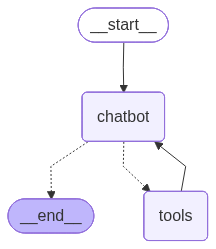

In [36]:
# Step 5: Compile the Graph
graph = graph_builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

## Part 4 — Gradio UI (No Memory)

Launch a chat interface. Each message triggers one graph invocation — conversation history is **not** persisted between calls yet.

In [37]:
def chat(user_input: str, history):
    result = graph.invoke({"messages": [{"role": "user", "content": user_input}]})
    return result["messages"][-1].content


gr.ChatInterface(chat, type="messages").launch()

* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.


Email sent: 6a33afc4e74054a08ef92b34


### Check LangSmith traces

Review your tool-calling runs at **https://smith.langchain.com/**

## Part 5 — Add Memory with `MemorySaver`

### Why isn't the graph already remembering?

A **super-step** is one full invocation of the graph (one user interaction). Reducers like `add_messages` merge updates *within* a super-step, but not *between* them. **Checkpointing** persists state across super-steps.

Recompile the graph with `checkpointer=MemorySaver()` and pass a `thread_id` in the config.

In [38]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

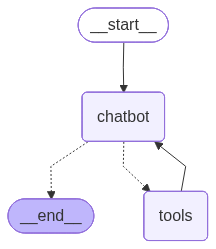

In [39]:
# Steps 1 and 2
graph_builder = StateGraph(State)


# Step 3
llm = ChatOpenAI(model="gpt-4o-mini")
llm_with_tools = llm.bind_tools(tools)

def chatbot(state: State):
    print(state)
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

graph_builder.add_node("chatbot", chatbot)
graph_builder.add_node("tools", ToolNode(tools=tools))

# Step 4
graph_builder.add_conditional_edges( "chatbot", tools_condition, "tools")
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")

# Step 5
graph = graph_builder.compile(checkpointer=memory)
display(Image(graph.get_graph().draw_mermaid_png()))

In [40]:
config = {"configurable": {"thread_id": "1"}}

def chat(user_input: str, history):
    result = graph.invoke({"messages": [{"role": "user", "content": user_input}]}, config=config)
    return result["messages"][-1].content


gr.ChatInterface(chat, type="messages").launch()

* Running on local URL:  http://127.0.0.1:7862
* To create a public link, set `share=True` in `launch()`.


{'messages': [HumanMessage(content='Hi what is my name?', additional_kwargs={}, response_metadata={}, id='aab80f97-5e01-4888-b1d6-679cacf46894')]}
{'messages': [HumanMessage(content='Hi what is my name?', additional_kwargs={}, response_metadata={}, id='aab80f97-5e01-4888-b1d6-679cacf46894'), AIMessage(content="I don't know your name yet. Could you please tell me?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 14, 'prompt_tokens': 95, 'total_tokens': 109, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_563536bfd0', 'id': 'chatcmpl-Ds2eQUb0wJMOag9zSXSunkDZGgAGb', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--895ff7ff-6789-4691-826d-10f39ad5b5f7-0', usage_metadata={'input_tokens': 95, 'ou

## Part 6 — Inspect State & History

Use `graph.get_state()` and `graph.get_state_history()` to inspect persisted conversation state. LangGraph also supports rewinding to a prior checkpoint and branching from there.

In [41]:
graph.get_state(config)

StateSnapshot(values={'messages': [HumanMessage(content='Hi what is my name?', additional_kwargs={}, response_metadata={}, id='aab80f97-5e01-4888-b1d6-679cacf46894'), AIMessage(content="I don't know your name yet. Could you please tell me?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 14, 'prompt_tokens': 95, 'total_tokens': 109, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_563536bfd0', 'id': 'chatcmpl-Ds2eQUb0wJMOag9zSXSunkDZGgAGb', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--895ff7ff-6789-4691-826d-10f39ad5b5f7-0', usage_metadata={'input_tokens': 95, 'output_tokens': 14, 'total_tokens': 109, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio':

In [42]:
# Most recent first

list(graph.get_state_history(config))

[StateSnapshot(values={'messages': [HumanMessage(content='Hi what is my name?', additional_kwargs={}, response_metadata={}, id='aab80f97-5e01-4888-b1d6-679cacf46894'), AIMessage(content="I don't know your name yet. Could you please tell me?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 14, 'prompt_tokens': 95, 'total_tokens': 109, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_563536bfd0', 'id': 'chatcmpl-Ds2eQUb0wJMOag9zSXSunkDZGgAGb', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--895ff7ff-6789-4691-826d-10f39ad5b5f7-0', usage_metadata={'input_tokens': 95, 'output_tokens': 14, 'total_tokens': 109, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio'

### Checkpointing & time travel

LangGraph lets you rewind to a prior checkpoint and branch off:

```python
config = {"configurable": {"thread_id": "1", "checkpoint_id": ...}}
graph.invoke(None, config=config)
```

This enables stable, recoverable agent systems.

## Part 7 — Persist to SQLite

Swap `MemorySaver` for `SqliteSaver` to store checkpoints in `memory.db`. State now survives notebook restarts.

In [43]:
import sqlite3
from langgraph.checkpoint.sqlite import SqliteSaver

db_path = "memory.db"
conn = sqlite3.connect(db_path, check_same_thread=False)
sql_memory = SqliteSaver(conn)

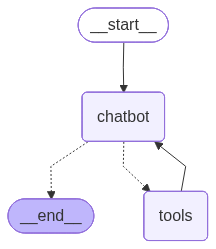

In [44]:
# Steps 1 and 2
graph_builder = StateGraph(State)


# Step 3
llm = ChatOpenAI(model="gpt-4o-mini")
llm_with_tools = llm.bind_tools(tools)

def chatbot(state: State):
    print(state)
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

graph_builder.add_node("chatbot", chatbot)
graph_builder.add_node("tools", ToolNode(tools=tools))

# Step 4
graph_builder.add_conditional_edges( "chatbot", tools_condition, "tools")
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")

# Step 5
graph = graph_builder.compile(checkpointer=sql_memory)
display(Image(graph.get_graph().draw_mermaid_png()))
 

In [45]:
config = {"configurable": {"thread_id": "3"}}

def chat(user_input: str, history):
    result = graph.invoke({"messages": [{"role": "user", "content": user_input}]}, config=config)
    return result["messages"][-1].content


gr.ChatInterface(chat, type="messages").launch()

* Running on local URL:  http://127.0.0.1:7863
* To create a public link, set `share=True` in `launch()`.


---

## Next Steps

Test memory by asking the bot your name across multiple messages. Review traces on **https://smith.langchain.com/** and inspect `memory.db`.

Try adding a third tool, switching `thread_id` for separate conversations, or rewinding to an earlier checkpoint.